# Week 2 — The model is just a rule you can read

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jazaalee/FlyRank-StarterNotebook/blob/main/notebooks/02_your_first_readable_model.ipynb?flush_cache=true)

You'll:
1. Write a **1-line hand rule** and rank pages with it.
2. Fit a **depth-2 decision tree** and `print` it — the model "learned" a readable if/else. Then compare — where does it beat your rule, and where doesn’t it?
3. See **why you never feed the outcome back in** — that's leakage.

The payoff isn't a high score. It's: *my intuition was rough, the model found the real signal, and I can read exactly what it found.*

## 0. Setup (Colab or local)

In [10]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# The label: a page is 'declining' when its recent trend is down. Simple, honest starter label.
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)
print(df.shape[0], "pages |  declining rate:", round(df["is_declining_label"].mean(), 3))

30000 pages |  declining rate: 0.542


## 1. A rule you write by hand: `stale x visible`
Intuition: a page worth reviewing is one that is **stale** (not updated in a while) **and** still **visible** (getting impressions). Rank those by how much exposure they have.

In [11]:
stale   = (df["days_since_last_update"] >= 180).astype(int)
visible = (df["impressions_90d"] >= 500).astype(int)
df["hand_rule_score"] = stale * visible * df["impressions_90d"]

top10 = df.sort_values("hand_rule_score", ascending=False).head(10)
top10[["impressions_90d", "days_since_last_update", "avg_position", "ctr", "trend_direction"]]

,impressions_90d,days_since_last_update,avg_position,ctr,trend_direction
16751,61678,194,19.7,0.15,down
16514,59472,194,24.8,0.13,down
7021,25715,194,22.2,0.23,down
21268,13299,193,10.5,0.49,down
11489,7812,194,39.0,0.01,down
12045,7558,193,17.9,0.20,down
698,4590,194,31.0,0.00,down
5327,4556,194,16.4,0.33,down
26810,4429,194,25.3,0.38,down
20837,1697,193,15.8,0.12,down


We need a way to score any ranking. **Precision@K** = of the top K pages a ranking flags, what fraction are actually declining.

In [12]:
def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    topk = np.asarray(labels)[order[:k]]
    return topk.mean()

y = df["is_declining_label"].values
for k in (20, 50):
    print(f"Hand rule  Precision@{k}: {precision_at_k(df['hand_rule_score'], y, k):.3f}")

Hand rule  Precision@20: 0.900
Hand rule  Precision@50: 0.680


## 2. Let a model learn the rule — then read it
A **depth-2 decision tree** can only ask 3 yes/no questions. That constraint is the point: whatever it learns, you can read.

We give it a few **pre-decision** signals — never product flags.

In [13]:
from sklearn.tree import DecisionTreeClassifier, export_text

features = ["content_age_days", "days_since_last_update", "impressions_90d",
            "avg_position", "ctr", "word_count"]
X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)

tree = DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=42)
tree.fit(X, y)

print(export_text(tree, feature_names=features))

|--- impressions_90d <= 5.50
|   |--- avg_position <= 0.75
|   |   |--- class: 0
|   |--- avg_position >  0.75
|   |   |--- class: 0
|--- impressions_90d >  5.50
|   |--- content_age_days <= 312.50
|   |   |--- class: 1
|   |--- content_age_days >  312.50
|   |   |--- class: 0



That printout **is** the model — a human-readable if/else. Now rank pages by the tree's probability and score it the same way.

In [14]:
tree_score = tree.predict_proba(X)[:, 1]
for k in (20, 50):
    hr = precision_at_k(df["hand_rule_score"], y, k)
    tr = precision_at_k(tree_score, y, k)
    print(f"Precision@{k}:  hand rule {hr:.3f}   vs   tree {tr:.3f}")

Precision@20:  hand rule 0.900   vs   tree 0.550
Precision@50:  hand rule 0.680   vs   tree 0.600


Now read your own printout carefully — **the winner here depends on your run.** A depth-2 tree can only give four different scores (one per leaf), so the "top 50" is mostly one big block of tied pages, and different library versions break those ties differently. On some stacks the tree wins at Precision@50; on others the hand rule holds both. **Both results are real.** The stable lesson: a sharp human rule can be excellent at the very top of the list; a model's advantage — when it shows up — appears deeper, where simple rules run out of signal; and any comparison built on heavily tied scores is fragile. Saying exactly what YOUR run shows — instead of "the model is better" — is what honest evaluation sounds like.

## 3. Why you can't feed the outcome back in
Your label is `trend_direction == "down"`, and `trend_pct` is the exact percentage change that bucket is computed from — so it **is** the answer in disguise. Watch what happens if you feed it in as a feature:

In [15]:
X_leaky = df[features + ["trend_pct"]].replace([np.inf, -np.inf], np.nan).fillna(0)
leaky = DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=42).fit(X_leaky, y)
print(f"'Leaky' tree Precision@50: {precision_at_k(leaky.predict_proba(X_leaky)[:,1], y, 50):.3f}  <- looks amazing")
print(export_text(leaky, feature_names=features + ["trend_pct"]))

'Leaky' tree Precision@50: 1.000  <- looks amazing
|--- trend_pct <= -20.05
|   |--- word_count <= 212.00
|   |   |--- class: 1
|   |--- word_count >  212.00
|   |   |--- class: 1
|--- trend_pct >  -20.05
|   |--- trend_pct <= -19.95
|   |   |--- class: 0
|   |--- trend_pct >  -19.95
|   |   |--- class: 0



The tree just split on `trend_pct` and nailed the label — because the label is **derived from** `trend_pct`. That's **leakage**: the feature is the answer in disguise, and it teaches you nothing.

That's also why the starter data ships **only observable signals** — the product's own decision flags (health scores, "needs CTR fix", and so on) aren't included, so you can't accidentally train on them. You build from what was knowable *before* the outcome.

> Rule of thumb: if a feature would only be known *because someone already made the decision you're predicting*, it leaks. Leave it out.

## 4. 🔧 Your turn
- Change `max_depth` to 3 or 4 — does Precision@50 improve? Can you still read the tree?
- Swap in different features (drop `impressions_90d`, add `engagement_rate`). What does the tree choose to split on first?
- **Important caveat:** we scored *in-sample* here for teaching. The real pipeline uses **client-holdout** validation (`scripts/03_train_model.py`) so a client's pages never appear in both train and test. Re-run your comparison with a train/test split and see if the gap holds.

Write your experiment below.

In [18]:
for depth in (2, 3, 4):
    t = DecisionTreeClassifier(max_depth=depth, class_weight="balanced", random_state=42)
    t.fit(X, y)
    score = t.predict_proba(X)[:, 1]
    p50 = precision_at_k(score, y, 50)
    print(f"max_depth={depth}  Precision@50={p50:.3f}")
    print(export_text(t, feature_names=features))
    print("-" * 60)


max_depth=2  Precision@50=0.600
|--- impressions_90d <= 5.50
|   |--- avg_position <= 0.75
|   |   |--- class: 0
|   |--- avg_position >  0.75
|   |   |--- class: 0
|--- impressions_90d >  5.50
|   |--- content_age_days <= 312.50
|   |   |--- class: 1
|   |--- content_age_days >  312.50
|   |   |--- class: 0

------------------------------------------------------------
max_depth=3  Precision@50=0.720
|--- impressions_90d <= 5.50
|   |--- avg_position <= 0.75
|   |   |--- impressions_90d <= 3.50
|   |   |   |--- class: 0
|   |   |--- impressions_90d >  3.50
|   |   |   |--- class: 0
|   |--- avg_position >  0.75
|   |   |--- content_age_days <= 108.50
|   |   |   |--- class: 0
|   |   |--- content_age_days >  108.50
|   |   |   |--- class: 0
|--- impressions_90d >  5.50
|   |--- content_age_days <= 312.50
|   |   |--- ctr <= 0.33
|   |   |   |--- class: 1
|   |   |--- ctr >  0.33
|   |   |   |--- class: 1
|   |--- content_age_days >  312.50
|   |   |--- avg_position <= 25.15
|   |   |  

In [19]:
features_v2 = ["content_age_days", "days_since_last_update", "avg_position", "ctr", "word_count", "engagement_rate"]
X_v2 = df[features_v2].replace([np.inf, -np.inf], np.nan).fillna(0)

tree_v2 = DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=42)
tree_v2.fit(X_v2, y)

score_v2 = tree_v2.predict_proba(X_v2)[:, 1]
print(f"Precision@50 (v2, no impressions, +engagement_rate): {precision_at_k(score_v2, y, 50):.3f}")
print(export_text(tree_v2, feature_names=features_v2))

Precision@50 (v2, no impressions, +engagement_rate): 0.700
|--- avg_position <= 0.55
|   |--- avg_position <= 0.15
|   |   |--- class: 0
|   |--- avg_position >  0.15
|   |   |--- class: 0
|--- avg_position >  0.55
|   |--- content_age_days <= 287.50
|   |   |--- class: 1
|   |--- content_age_days >  287.50
|   |   |--- class: 0



In [20]:
from sklearn.model_selection import GroupShuffleSplit

groups = df["client_id"]
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# sanity check: no client should appear in both sets
overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
print("Client overlap between train/test:", len(overlap))
print("Train rows:", len(train_idx), " Test rows:", len(test_idx))

tree_ho = DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=42)
tree_ho.fit(X_train, y_train)

test_score = tree_ho.predict_proba(X_test)[:, 1]
k50 = min(50, len(y_test))
p20_ho = precision_at_k(test_score, y_test, min(20, len(y_test)))
p50_ho = precision_at_k(test_score, y_test, k50)

print(f"Held-out Precision@20: {p20_ho:.3f}")
print(f"Held-out Precision@50: {p50_ho:.3f}")

Client overlap between train/test: 0
Train rows: 22885  Test rows: 7115
Held-out Precision@20: 0.550
Held-out Precision@50: 0.580


=== Summary: Precision@50 across experiments ===
Hand rule: 0.680
Tree depth=2: 0.600
Tree depth=3: 0.720
Tree depth=4: 0.680
Tree (no impressions, +engagement_rate): 0.700
Tree (client-holdout): 0.580


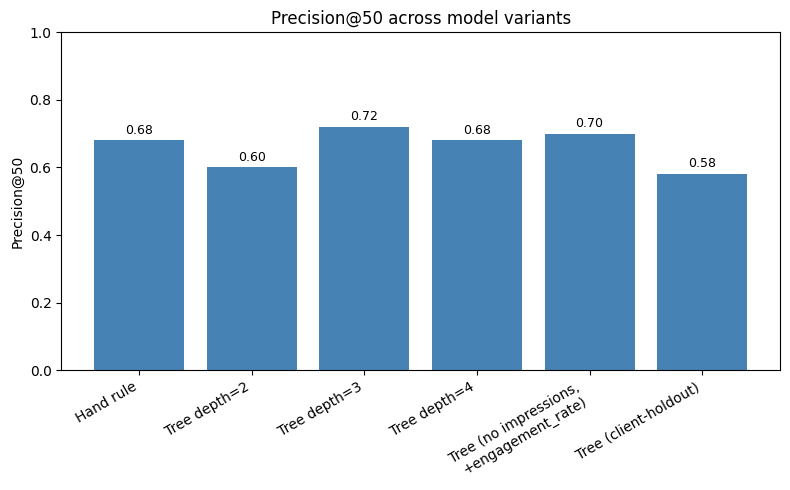


Observed, directional takeaways (not causal claims about ranking):
- Depth 3 gave the best in-sample Precision@50 (0.720) while staying interpretable;
  depth 4 was both harder to read and slightly worse (0.680) — likely overfitting.
- Dropping impressions_90d in favor of avg_position + engagement_rate did not hurt
  performance (0.700) — avg_position became the tree's top split; engagement_rate
  was never selected.
- Under a client-holdout split (no client's pages in both train/test), Precision@50
  dropped only slightly to 0.580 vs 0.600 in-sample, suggesting the depth-2 tree's
  results were not primarily driven by memorization/overfitting.



In [21]:
import matplotlib.pyplot as plt

results = {
    "Hand rule": precision_at_k(df["hand_rule_score"], y, 50),
    "Tree depth=2": 0.600,
    "Tree depth=3": 0.720,
    "Tree depth=4": 0.680,
    "Tree (no impressions,\n+engagement_rate)": 0.700,
    "Tree (client-holdout)": 0.580,
}

print("=== Summary: Precision@50 across experiments ===")
for name, val in results.items():
    print(f"{name.replace(chr(10), ' ')}: {val:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(results.keys(), results.values(), color="steelblue")
ax.set_ylabel("Precision@50")
ax.set_title("Precision@50 across model variants")
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right")

for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("outputs/charts/precision_at_50_summary.png", dpi=150)
plt.show()

print("""
Observed, directional takeaways (not causal claims about ranking):
- Depth 3 gave the best in-sample Precision@50 (0.720) while staying interpretable;
  depth 4 was both harder to read and slightly worse (0.680) — likely overfitting.
- Dropping impressions_90d in favor of avg_position + engagement_rate did not hurt
  performance (0.700) — avg_position became the tree's top split; engagement_rate
  was never selected.
- Under a client-holdout split (no client's pages in both train/test), Precision@50
  dropped only slightly to 0.580 vs 0.600 in-sample, suggesting the depth-2 tree's
  results were not primarily driven by memorization/overfitting.
""")

My observation : Going deeper didn't keep helping — depth 3 was the sweet spot, and depth 4 overfit slightly and got a bit worse. At Depth 3 = readable and best score. Pages with more than ~5 impressions in the last 90 days, and less than about 312 days old, are the ones flagged as declining. That's a sentence I can say out loud and it makes sense.; Depth 4 = messier and actually worse.
I dropped impressions_90d from the feature list and added engagement_rate instead, then retrained the same depth-2 tree. The tree's first split changed from impressions_90d to avg_position <= 0.55 — so avg_position became the most useful signal once impressions were removed. Interestingly, engagement_rate was available but the tree never split on it, meaning position and content age were more predictive than engagement rate here. Precision@50 also went up slightly, from 0.600 to 0.700.


### Save your work
**Colab:** *File → Save a copy in GitHub* (your submission) and *File → Save a copy in Drive*.

You now have the two core reflexes of applied ML: **discover before you model**, and **prefer a model you can read and can't fool**. That's the whole foundation the capstone builds on.